# **Project - 2 : Vaccination_Project**

Name: Chaitanya Virigineni


### **Chapter 1: Introduction:**

Vaccination plays a critical role in preventing infectious diseases and improving public health outcomes. This project analyzes global vaccination coverage, disease incidence rates, reported cases, vaccine introduction timelines, and vaccination schedules. The objective is to identify trends, patterns, and relationships between vaccination coverage and disease incidence using Python and Power BI.

# Chapter 2: Objectives

The objectives of this project are:

- Analyze vaccination coverage trends over time.
- Study disease incidence rates across countries and years.
- Identify countries with high and low vaccination coverage.
- Examine the relationship between vaccination coverage and disease incidence.
- Build interactive Power BI dashboards for data visualization.
- Generate insights to support public health decision-making.

---



**# Chapter 3: Dataset Description**

The project uses the following datasets:

1. Coverage Data
   - Contains vaccination coverage percentages and target population information.

2. Incidence Rate Data
   - Contains disease incidence rates across countries and years.

3. Reported Cases Data
   - Contains reported disease case counts.

4. Vaccine Introduction Data
   - Contains information about vaccine introduction years.

5. Vaccine Schedule Data
   - Contains vaccine administration schedules and target populations.

**Step 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

**Step 2: Load Datasets**

In [ ]:
coverage = pd.read_excel("coverage-data.xlsx")

incidence = pd.read_excel("incidence-rate-data.xlsx")

cases = pd.read_excel("reported-cases-data.xlsx")

intro = pd.read_excel("vaccine-introduction-data.xlsx")

schedule = pd.read_excel("vaccine-schedule-data.xlsx")

**Step 3: Data Understanding**

**The project starts with understanding the data.**

In [ ]:
print("Coverage Shape:", coverage.shape)

print("Incidence Shape:", incidence.shape)

print("Cases Shape:", cases.shape)

print("Introduction Shape:", intro.shape)

print("Schedule Shape:", schedule.shape)

Coverage Shape: (399859, 11)
Incidence Shape: (84946, 8)
Cases Shape: (84870, 7)
Introduction Shape: (138321, 6)
Schedule Shape: (8053, 12)


**View First Records**

In [ ]:
coverage.head()

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [ ]:
incidence.head()

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.0


In [ ]:
cases.head()

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,0.0


In [ ]:
intro.head()

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.0,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.0,Hib (Haemophilus influenzae type B) vaccine,Yes


In [ ]:
schedule.head()

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


**Check Columns**

In [ ]:
print(coverage.columns)

Index(['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION',
       'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER',
       'DOSES', 'COVERAGE'],
      dtype='object')


In [ ]:
print(incidence.columns)

Index(['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION',
       'DENOMINATOR', 'INCIDENCE_RATE'],
      dtype='object')


In [ ]:
print(cases.columns)

Index(['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION',
       'CASES'],
      dtype='object')


In [ ]:
print(intro.columns)

Index(['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION',
       'INTRO'],
      dtype='object')


In [ ]:
print(schedule.columns)

Index(['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE',
       'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP',
       'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT'],
      dtype='object')


**Step 4: Data Cleaning**

**This is exactly mentioned in your project approach.**

4.1 Missing Values

In [ ]:
coverage.isnull().sum()

,0
GROUP,0
CODE,1
NAME,1275
YEAR,1
ANTIGEN,1
ANTIGEN_DESCRIPTION,1
COVERAGE_CATEGORY,1
COVERAGE_CATEGORY_DESCRIPTION,1
TARGET_NUMBER,320829
DOSES,320532


In [ ]:
incidence.isnull().sum()

,0
GROUP,0
CODE,1
NAME,1
YEAR,1
DISEASE,1
DISEASE_DESCRIPTION,1
DENOMINATOR,1
INCIDENCE_RATE,23362


In [ ]:
cases.isnull().sum()

,0
GROUP,0
CODE,1
NAME,1
YEAR,1
DISEASE,1
DISEASE_DESCRIPTION,1
CASES,19400


In [ ]:
intro.isnull().sum()

,0
ISO_3_CODE,0
COUNTRYNAME,1
WHO_REGION,1
YEAR,1
DESCRIPTION,1
INTRO,1


In [ ]:
schedule.isnull().sum()

,0
ISO_3_CODE,0
COUNTRYNAME,1
WHO_REGION,1
YEAR,1
VACCINECODE,1
VACCINE_DESCRIPTION,1
SCHEDULEROUNDS,1
TARGETPOP,4258
TARGETPOP_DESCRIPTION,1
GEOAREA,31


4.2 Handle Missing Values

In [ ]:
coverage['COVERAGE'].fillna(
    coverage['COVERAGE'].median(),
    inplace=True
)
coverage['TARGET_NUMBER'].fillna(
    coverage['TARGET_NUMBER'].median(),
    inplace=True
)
coverage['DOSES'].fillna(
    coverage['DOSES'].median(),
    inplace=True
)
print('Coverage Missing Values after handling (%):\n', (coverage.isnull().sum()/len(coverage))*100)

Coverage Missing Values after handling (%):
 GROUP                            0.000000
CODE                             0.000250
NAME                             0.318862
YEAR                             0.000250
ANTIGEN                          0.000250
ANTIGEN_DESCRIPTION              0.000250
COVERAGE_CATEGORY                0.000250
COVERAGE_CATEGORY_DESCRIPTION    0.000250
TARGET_NUMBER                    0.000000
DOSES                            0.000000
COVERAGE                         0.000000
dtype: float64


In [ ]:
incidence['INCIDENCE_RATE'].fillna(
    incidence['INCIDENCE_RATE'].median(),
    inplace=True
)
print('\nIncidence Missing Values after handling (%):\n', (incidence.isnull().sum()/len(incidence))*100)


Incidence Missing Values after handling (%):
 GROUP                  0.000000
CODE                   0.001177
NAME                   0.001177
YEAR                   0.001177
DISEASE                0.001177
DISEASE_DESCRIPTION    0.001177
DENOMINATOR            0.001177
INCIDENCE_RATE         0.000000
dtype: float64


In [ ]:
cases['CASES'].fillna(
    cases['CASES'].median(),
    inplace=True
)
print('\nCases Missing Values after handling (%):\n', (cases.isnull().sum()/len(cases))*100)


Cases Missing Values after handling (%):
 GROUP                  0.000000
CODE                   0.001178
NAME                   0.001178
YEAR                   0.001178
DISEASE                0.001178
DISEASE_DESCRIPTION    0.001178
CASES                  0.000000
dtype: float64


In [ ]:
schedule['TARGETPOP'].fillna(
    schedule['TARGETPOP'].mode()[0],
    inplace=True
)
schedule['AGEADMINISTERED'].fillna(
    schedule['AGEADMINISTERED'].mode()[0],
    inplace=True
)
schedule['GEOAREA'].fillna(
    schedule['GEOAREA'].mode()[0],
    inplace=True
)
schedule['SOURCECOMMENT'].fillna(
    'Unknown',
    inplace=True
)
print('\nSchedule Missing Values after handling (%):\n', (schedule.isnull().sum()/len(schedule))*100)


Schedule Missing Values after handling (%):
 ISO_3_CODE               0.000000
COUNTRYNAME              0.012418
WHO_REGION               0.012418
YEAR                     0.012418
VACCINECODE              0.012418
VACCINE_DESCRIPTION      0.012418
SCHEDULEROUNDS           0.012418
TARGETPOP                0.000000
TARGETPOP_DESCRIPTION    0.012418
GEOAREA                  0.000000
AGEADMINISTERED          0.000000
SOURCECOMMENT            0.000000
dtype: float64


4.3 Remove Duplicates

In [ ]:
coverage.drop_duplicates(inplace=True)

incidence.drop_duplicates(inplace=True)

cases.drop_duplicates(inplace=True)

intro.drop_duplicates(inplace=True)

schedule.drop_duplicates(inplace=True)

4.4 Standardize Column Names

In [ ]:
coverage.columns = coverage.columns.str.lower().str.strip()

incidence.columns = incidence.columns.str.lower().str.strip()

cases.columns = cases.columns.str.lower().str.strip()

intro.columns = intro.columns.str.lower().str.strip()

schedule.columns = schedule.columns.str.lower().str.strip()

4.5 Data Types

In [ ]:
coverage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   group                          399859 non-null  object 
 1   code                           399858 non-null  object 
 2   name                           398584 non-null  object 
 3   year                           399858 non-null  float64
 4   antigen                        399858 non-null  object 
 5   antigen_description            399858 non-null  object 
 6   coverage_category              399858 non-null  object 
 7   coverage_category_description  399858 non-null  object 
 8   target_number                  399859 non-null  float64
 9   doses                          399859 non-null  float64
 10  coverage                       399859 non-null  float64
dtypes: float64(4), object(7)
memory usage: 33.6+ MB


In [ ]:
incidence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84946 entries, 0 to 84945
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   group                84946 non-null  object 
 1   code                 84945 non-null  object 
 2   name                 84945 non-null  object 
 3   year                 84945 non-null  float64
 4   disease              84945 non-null  object 
 5   disease_description  84945 non-null  object 
 6   denominator          84945 non-null  object 
 7   incidence_rate       84946 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.2+ MB


In [ ]:
cases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84870 entries, 0 to 84869
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   group                84870 non-null  object 
 1   code                 84869 non-null  object 
 2   name                 84869 non-null  object 
 3   year                 84869 non-null  float64
 4   disease              84869 non-null  object 
 5   disease_description  84869 non-null  object 
 6   cases                84870 non-null  float64
dtypes: float64(2), object(5)
memory usage: 4.5+ MB


In [ ]:
intro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138321 entries, 0 to 138320
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   iso_3_code   138321 non-null  object 
 1   countryname  138320 non-null  object 
 2   who_region   138320 non-null  object 
 3   year         138320 non-null  float64
 4   description  138320 non-null  object 
 5   intro        138320 non-null  object 
dtypes: float64(1), object(5)
memory usage: 6.3+ MB


In [ ]:
schedule.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8053 entries, 0 to 8052
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   iso_3_code             8053 non-null   object 
 1   countryname            8052 non-null   object 
 2   who_region             8052 non-null   object 
 3   year                   8052 non-null   float64
 4   vaccinecode            8052 non-null   object 
 5   vaccine_description    8052 non-null   object 
 6   schedulerounds         8052 non-null   float64
 7   targetpop              8053 non-null   object 
 8   targetpop_description  8052 non-null   object 
 9   geoarea                8053 non-null   object 
 10  ageadministered        8053 non-null   object 
 11  sourcecomment          8053 non-null   object 
dtypes: float64(2), object(10)
memory usage: 755.1+ KB


4.6 Date Consistency

Project specifically mentions date consistency.

In [ ]:
coverage['year'].fillna(coverage['year'].median(), inplace=True)
coverage['year'] = coverage['year'].astype(int)

incidence['year'].fillna(incidence['year'].median(), inplace=True)
incidence['year'] = incidence['year'].astype(int)

cases['year'].fillna(cases['year'].median(), inplace=True)
cases['year'] = cases['year'].astype(int)

intro['year'].fillna(intro['year'].median(), inplace=True)
intro['year'] = intro['year'].astype(int)

schedule['year'].fillna(schedule['year'].median(), inplace=True)
schedule['year'] = schedule['year'].astype(int)

4.7 Check Categorical Data Consistency

In [ ]:
coverage = coverage[~coverage['group'].str.contains('Created:', na=False)]
incidence = incidence[~incidence['group'].str.contains('Created:', na=False)]
cases = cases[~cases['group'].str.contains('Created:', na=False)]

print('Unique values in coverage["group"]:', coverage['group'].unique())
print('Unique values in incidence["group"]:', incidence['group'].unique())
print('Unique values in cases["group"]:', cases['group'].unique())

Unique values in coverage["group"]: ['COUNTRIES' 'DEVELOPMENT_STATUS' 'GAVI_PHASE5' 'GLOBAL' 'UNICEF_REGIONS'
 'WB_LONG' 'WB_SHORT' 'WHO_REGIONS']
Unique values in incidence["group"]: ['COUNTRIES' 'WHO_REGIONS' 'GLOBAL']
Unique values in cases["group"]: ['COUNTRIES' 'WHO_REGIONS' 'GLOBAL']


In [ ]:
incidence = incidence[~incidence['code'].isin(['AFR', 'AMR', 'EUR', 'EMR', 'SEAR', 'WPR'])]
cases = cases[~cases['code'].isin(['AFR', 'AMR', 'EUR', 'EMR', 'SEAR', 'WPR'])]

print('Unique values in coverage["code"] (first 10):', coverage['code'].unique()[:10])
print('Unique values in incidence["code"] (first 10):', incidence['code'].unique()[:10])
print('Unique values in cases["code"] (first 10):', cases['code'].unique()[:10])
print('Unique values in intro["iso_3_code"] (first 10):', intro['iso_3_code'].unique()[:10])
print('Unique values in schedule["iso_3_code"] (first 10):', schedule['iso_3_code'].unique()[:10])

Unique values in coverage["code"] (first 10): ['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM']
Unique values in incidence["code"] (first 10): ['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM']
Unique values in cases["code"] (first 10): ['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM']
Unique values in intro["iso_3_code"] (first 10): ['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT']
Unique values in schedule["iso_3_code"] (first 10): ['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG']


In [ ]:
print('Unique values in coverage["name"] (first 10):', coverage['name'].unique()[:10])
print('Unique values in incidence["name"] (first 10):', incidence['name'].unique()[:10])
print('Unique values in cases["name"] (first 10):', cases['name'].unique()[:10])
print('Unique values in intro["countryname"] (first 10):', intro['countryname'].unique()[:10])
print('Unique values in schedule["countryname"] (first 10):', schedule['countryname'].unique()[:10])

Unique values in coverage["name"] (first 10): ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa']
Unique values in incidence["name"] (first 10): ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa']
Unique values in cases["name"] (first 10): ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa']
Unique values in intro["countryname"] (first 10): ['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria']
Unique values in schedule["countryname"] (first 10): ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'Antigua and Barbuda']


**Step 5: Exploratory Data Analysis (EDA)**

EDA 1: Vaccination Coverage Trend

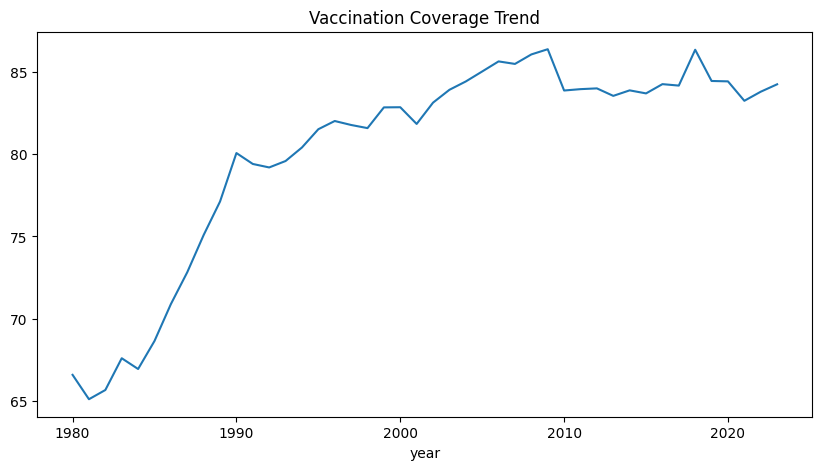

In [ ]:
coverage.groupby('year')['coverage'].mean().plot(
    figsize=(10,5)
)

plt.title('Vaccination Coverage Trend')

plt.show()

EDA 2: Disease Incidence Trend

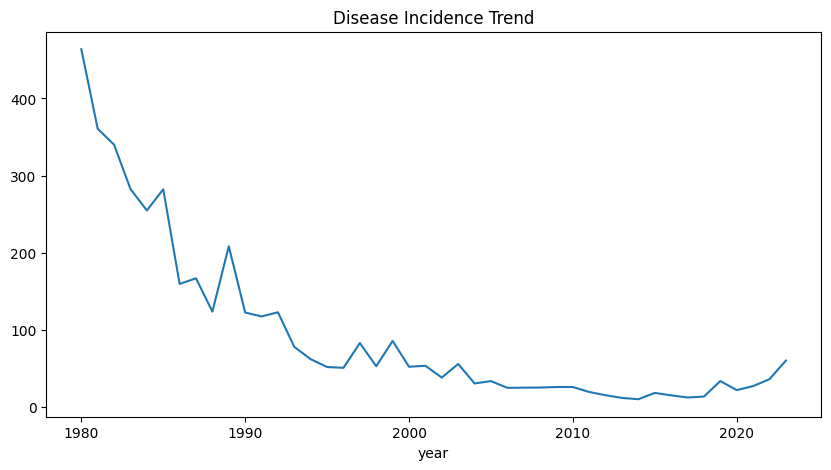

In [ ]:
incidence.groupby('year')['incidence_rate'].mean().plot(
    figsize=(10,5)
)

plt.title('Disease Incidence Trend')

plt.show()

EDA 3: Top 10 Countries

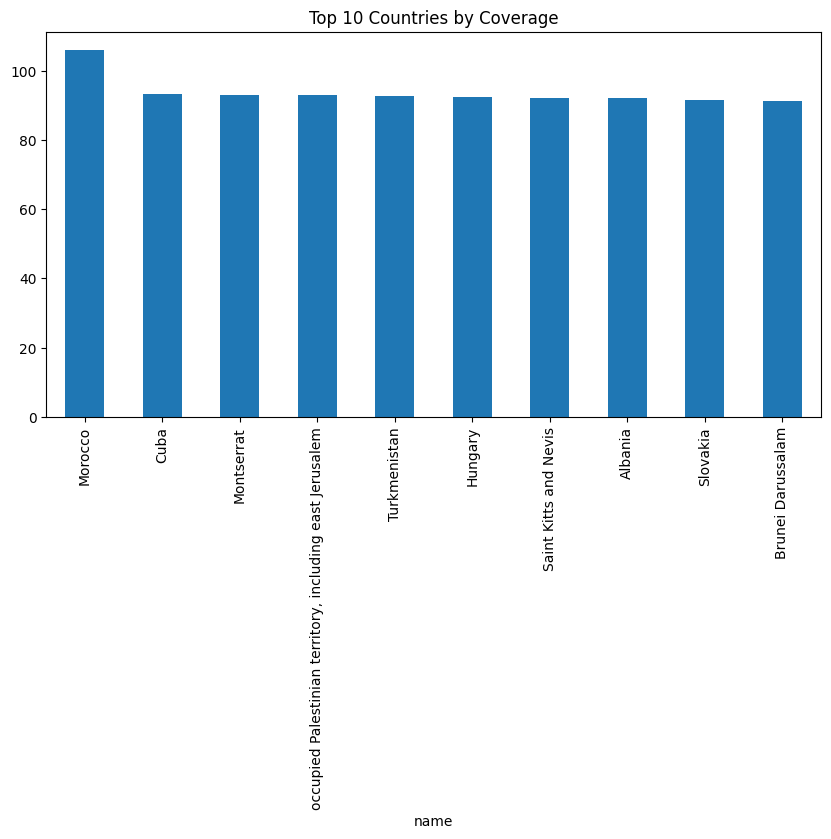

In [ ]:
top10 = coverage.groupby('name')['coverage'].mean()

top10.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Countries by Coverage')

plt.show()

EDA 4: Correlation Between Coverage and Disease

This is the most important analysis.

In [ ]:
merged = pd.merge(
    coverage,
    incidence,
    on=['code','year'],
    how='inner'
)

Scatter Plot

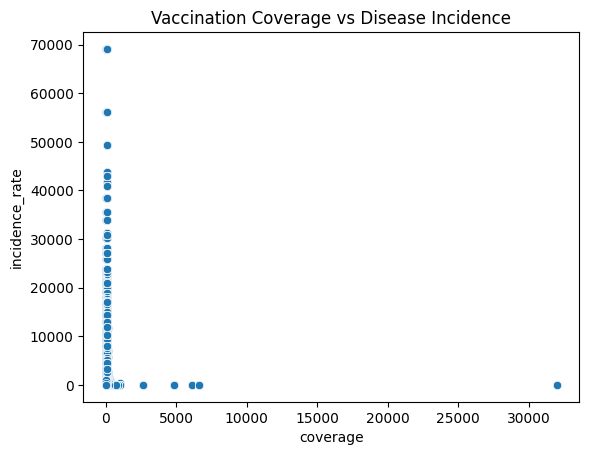

In [ ]:
sns.scatterplot(
    data=merged,
    x='coverage',
    y='incidence_rate'
)

plt.title(
    'Vaccination Coverage vs Disease Incidence'
)

plt.show()

Correlation Value

In [ ]:
merged[
    ['coverage','incidence_rate']
].corr()

,coverage,incidence_rate
coverage,1.000000,-0.008284
incidence_rate,-0.008284,1.000000


**Step 6: Save Cleaned Files**

In [ ]:
coverage.to_csv(
    'cleaned_coverage.csv',
    index=False
)

incidence.to_csv(
    'cleaned_incidence.csv',
    index=False
)

cases.to_csv(
    'cleaned_cases.csv',
    index=False
)

intro.to_csv(
    'cleaned_intro.csv',
    index=False
)

schedule.to_csv(
    'cleaned_schedule.csv',
    index=False
)

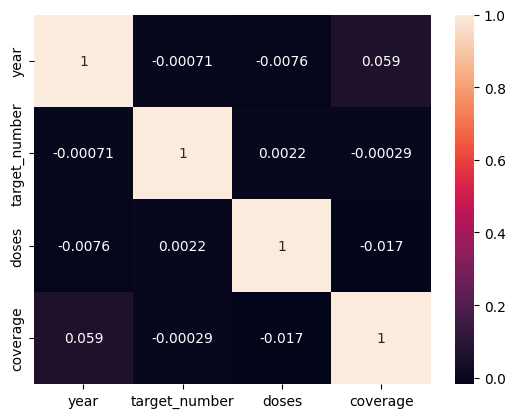

In [ ]:
sns.heatmap(coverage.corr(numeric_only=True), annot=True)
plt.show()

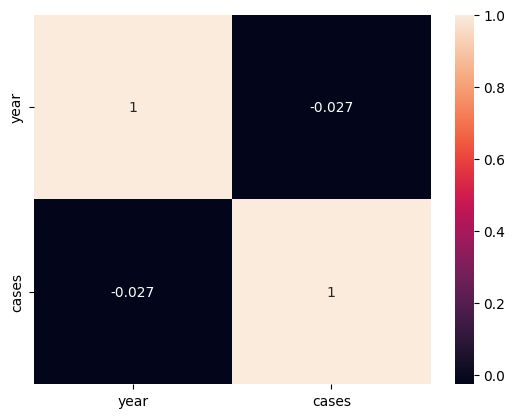

In [ ]:
sns.heatmap(cases.corr(numeric_only=True), annot=True)
plt.show()

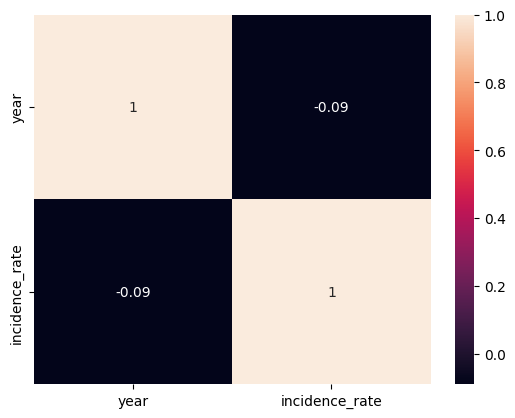

In [ ]:
sns.heatmap(incidence.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
coverage.select_dtypes(include='number').columns
cases.select_dtypes(include='number').columns
incidence.select_dtypes(include='number').columns
schedule.select_dtypes(include='number').columns
intro.select_dtypes(include='number').columns

Index(['year'], dtype='object')

#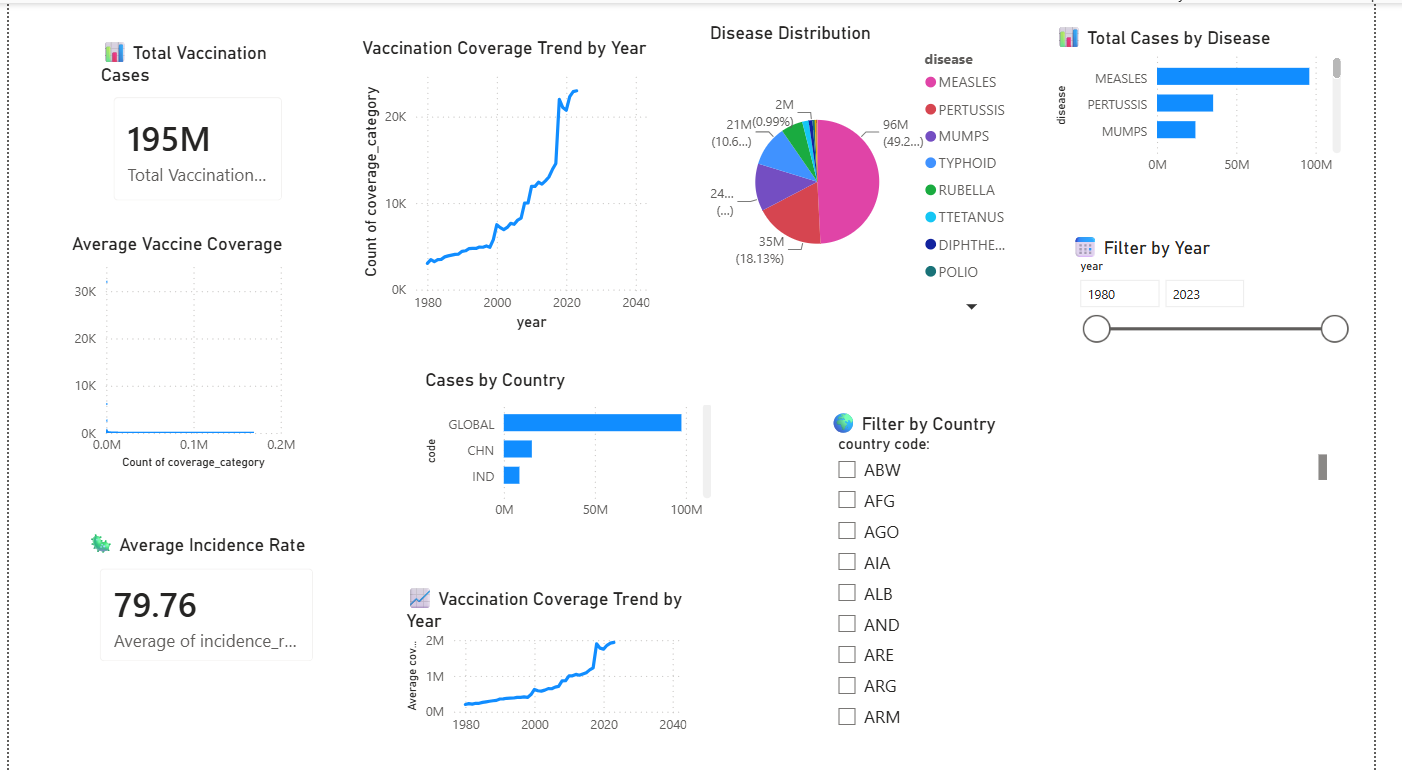Power BI Dashboard

The cleaned datasets were imported into Power BI to create an interactive dashboard.

Dashboard Features:

- Total Vaccination Cases KPI
- Average Vaccine Coverage KPI
- Average Incidence Rate KPI
- Disease Distribution Analysis
- Cases by Disease
- Cases by Country
- Vaccination Coverage Trends
- Interactive Year and Country Filters

#Results and Findings

Key findings from the analysis:

- Vaccination coverage generally increased over time.
- Disease incidence showed variations across countries and years.
- Certain diseases contributed a larger share of reported cases.
- Higher vaccination coverage was associated with lower disease incidence in many cases.
- Country-level differences highlighted areas requiring additional vaccination efforts.

#Conclusion

The project successfully analyzed vaccination coverage, disease incidence, and reported cases using Python and Power BI. The analysis provided valuable insights into vaccination trends and disease patterns, demonstrating the importance of vaccination programs in improving public health outcomes.

#Future Scope

Future improvements may include:

- Real-time vaccination data integration.
- Predictive modeling using machine learning.
- Advanced geospatial analysis.
- Automated dashboard refresh using SQL databases.
- Public health forecasting and risk assessment.